In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys

sys.path.append("../slr-cnn/plotting")
from loss_plots import LossPlots

In [2]:
model_names = [
    "cnn",
    "unet",
    "vit"
]
actual_names = [
    "CNN",
    "UNet",
    "ViT"
]

In [3]:
# CNN losses
train_loss_unet = [
    132.1318, 57.4524, 20.2817, 17.0074, 16.8387,
    16.5468, 16.4196, 16.1702, 15.9634, 15.8672,
    15.7314, 15.5859, 15.4957, 15.3383, 15.2718
]

val_loss_unet = [
    86.2199, 24.8429, 16.8524, 16.5019, 16.3259,
    16.9153, 16.5783, 15.7635, 16.1685, 16.3835,
    16.0071, 15.7683, 15.7510, 16.0213, 16.5557
]

# UNet losses
train_loss_cnn = [
    20.9494, 18.2488, 18.4310, 17.2494, 17.6138, 17.2937, 16.7710, 16.6707, 16.8065, 16.3368,
    16.5258, 16.1844, 16.1165, 15.8562, 15.8683
]

val_loss_cnn = [
    17.8897, 17.6874, 16.6518, 18.6298, 16.5969, 16.1197, 16.1685, 16.2144, 16.4420, 16.3630,
    23.8474, 16.5326, 17.2104, 16.4869, 16.1456
]
# Combine into a long-format DataFrame
epochs = list(range(1,16))

df = pd.DataFrame({
    "Epoch": epochs * 4,
    "Loss": train_loss_cnn + val_loss_cnn + train_loss_unet + val_loss_unet,
    "Set": ["Train"] * 15 + ["Val"] * 15 + ["Train"] * 15 + ["Val"] * 15,
    "Model": ["CNN"] * 30 + ["UNet"] * 30
})

print(df.head())

   Epoch     Loss    Set Model
0      1  20.9494  Train   CNN
1      2  18.2488  Train   CNN
2      3  18.4310  Train   CNN
3      4  17.2494  Train   CNN
4      5  17.6138  Train   CNN


In [4]:
# Extract lists of loss values for each model and set
train_loss_cnn = df[(df["Model"] == "CNN") & (df["Set"] == "Train")]["Loss"].tolist()
val_loss_cnn = df[(df["Model"] == "CNN") & (df["Set"] == "Val")]["Loss"].tolist()
train_loss_unet = df[(df["Model"] == "UNet") & (df["Set"] == "Train")]["Loss"].tolist()
val_loss_unet = df[(df["Model"] == "UNet") & (df["Set"] == "Val")]["Loss"].tolist()

# Combine them into list-of-lists as required by your class
train_loss = [train_loss_cnn, train_loss_unet]
val_loss = [val_loss_cnn, val_loss_unet]

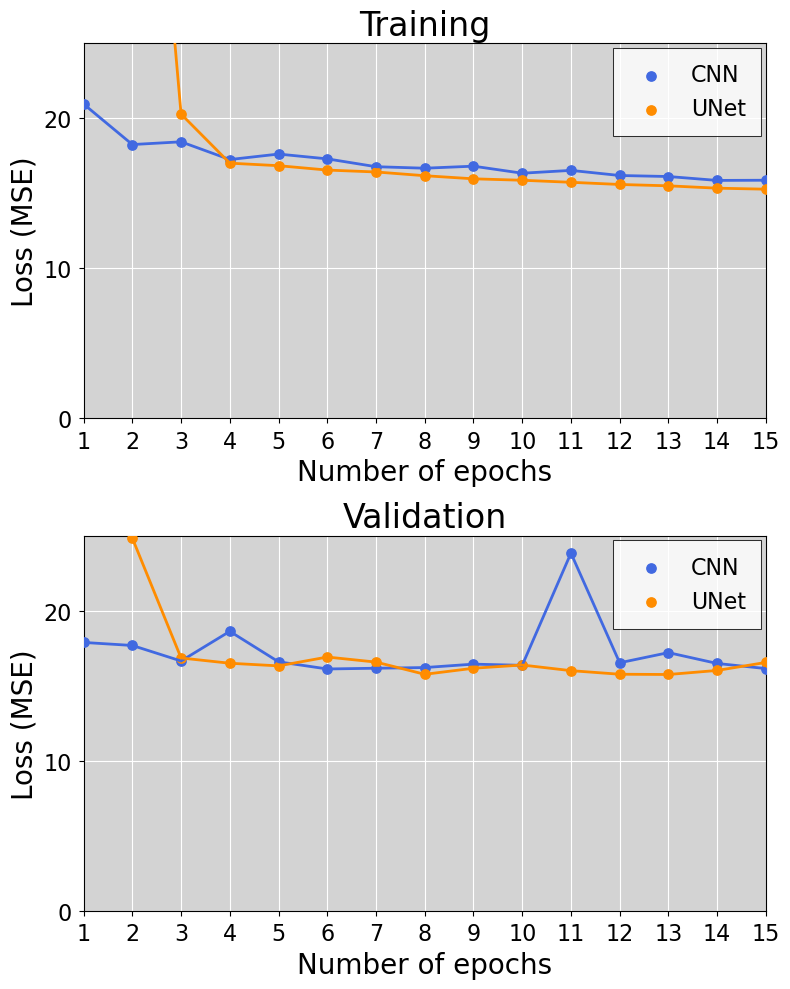

In [5]:
# Initialize the LossPlots class
plotter = LossPlots(
    model_type=["CNN", "UNet"],        # labels for legend
    num_epochs=15,                     # number of epochs
    fname="loss_plot.png",             # filename to save (if needed)
    colors=["royalblue", "darkorange"],# colors for each model
    fsave=False                        # set to True if you want to save
)

# Plot training and validation losses
plotter.make_plot(train_loss, val_loss)
plt.show()

In [6]:
#loss_plot = loss_plots.LossPlots(model_names, n